# Pipeline CD - Coleta de Dados
## Trilha C: risco de baixa produtividade agrícola
### ETAPA 1 - Coleta e preservação do dado bruto

1. **Configuração**: parâmetros de local, período e variáveis reunidos em um único lugar;
2. **Coleta**: requisições às duas APIs da Trilha C (NASA POWER e IBGE/PAM), com timeout e tratamento de erro;
3. **Preservação do dado bruto**: a resposta original de cada API é salva em disco antes de qualquer transformação.



## 1. Definição do problema


- **Evento a prever:** Risco de baixa produtividade da lavoura de soja em Piracicaba-SP.
- **Horizonte:** por safra (uma linha = uma safra de soja no município).
- **Recorte geográfico:** Piracicaba-SP (código IBGE 3538709).
- **Período:** safras 2015 a 2025.
- **Unidade de análise:** ano-safra de soja em Piracicaba-SP.
- **Informações disponíveis no momento real da previsão:** dados climáticos da janela de plantio/desenvolvimento (Setembro do ano anterior a Abril do ano da safra) variáveis agrícolas do IBGE (área, quantidade, rendimento) só existem **depois** da colheita e por isso não podem virar feature, apenas alvo.
- **Custo do falso negativo:** não prever uma safra de baixa produtividade significa que o produtor não antecipa medidas de mitigação (irrigação suplementar, ajuste de insumos, seguro agrícola), aumentando o prejuízo financeiro quando o evento realmente ocorre.

In [ ]:
import json
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuração da coleta

Todos os parâmetros usados nas duas coletas ficam aqui — nada de valores soltos pelo notebook.

In [ ]:
config = {
    "local": "Piracicaba-SP",
    "latitude": -22.7253,
    "longitude": -47.6492,
    "data_inicial": "2015-01-01",
    "data_final": "2025-12-31",
    "ano_inicial": 2015,
    "ano_final": 2025,
    "timezone": "America/Sao_Paulo",
    "cultura": "Soja (em grão)",
}

os.makedirs("dados_brutos", exist_ok=True)

config

{'local': 'Piracicaba-SP',
 'latitude': -22.7253,
 'longitude': -47.6492,
 'data_inicial': '2015-01-01',
 'data_final': '2025-12-31',
 'ano_inicial': 2015,
 'ano_final': 2025,
 'timezone': 'America/Sao_Paulo',
 'cultura': 'Soja (em grão)'}

## 3. Fontes escolhidas

Conforme a Tabela de Decisão Ponderada da ficha de investigação (IBGE = 22 pontos, NASA POWER = 21 pontos):

| Fonte | Papel no projeto | Justificativa |
|---|---|---|
| **IBGE — API de Dados Agregados (PAM, tabela 1612)** | Fornece a variável-alvo (rendimento médio, kg/ha) e atributos de área/produção | Única fonte com o dado de produtividade por município e cultura |
| **NASA POWER Daily API** | Fornece as variáveis climáticas explicativas | Cobertura temporal mais longa e melhor compatibilidade com as demais fontes que o Open-Meteo (usado aqui apenas como fallback documentado) |

WHO/OMS e WMO/OMM **não** entram como coleta — são usadas só para fundamentar limiares e interpretar resultados na ETAPA 2.

## 4. Coleta 1 — Clima agrícola (NASA POWER Daily API)

Variáveis selecionadas — cada uma com justificativa ligada ao problema (registradas no dicionário de dados do grupo):

| Variável | Justificativa |
|---|---|
| `PRECTOTCORR` | precipitação: indicador direto de déficit/excesso hídrico na safra |
| `T2M` | temperatura média: estresse térmico geral da cultura |
| `T2M_MAX` | temperatura máxima: dias de calor extremo |
| `T2M_MIN` | temperatura mínima: risco de frio/geada no início do ciclo |
| `RH2M` | umidade relativa: combinada com temperatura para déficit hídrico |
| `GWETROOT` | umidade do solo na zona radicular: proxy direto de seca agrícola |

In [ ]:
url_clima_agricola = "https://power.larc.nasa.gov/api/temporal/daily/point"

variaveis_climaticas = [
    "PRECTOTCORR",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "GWETROOT",
]

parametros_clima_agricola = {
    "parameters": ",".join(variaveis_climaticas),
    "community": "AG",  # Agroclimatology: unidades e variáveis voltadas à agricultura
    "longitude": config["longitude"],
    "latitude": config["latitude"],
    "start": config["data_inicial"].replace("-", ""),
    "end": config["data_final"].replace("-", ""),
    "format": "JSON",
}

try:
    resposta_clima_agricola = requests.get(
        url_clima_agricola,
        params=parametros_clima_agricola,
        timeout=60,
    )
    resposta_clima_agricola.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

Requisição concluída.


### Inspecionar a resposta antes de transformar

In [ ]:
print("Status:", resposta_clima_agricola.status_code)
print("Content-Type:", resposta_clima_agricola.headers.get("Content-Type"))
print("URL consultada:", resposta_clima_agricola.url)

dados_clima_agricola = resposta_clima_agricola.json()

# Validação do esquema esperado -- não presumimos que a chave existe
assert "properties" in dados_clima_agricola, "Chave 'properties' ausente na resposta."
assert "parameter" in dados_clima_agricola["properties"], "Chave 'parameter' ausente em 'properties'."

print("Variáveis retornadas:", list(dados_clima_agricola["properties"]["parameter"].keys()))

Status: 200
Content-Type: application/json
URL consultada: https://power.larc.nasa.gov/api/temporal/daily/point?parameters=PRECTOTCORR%2CT2M%2CT2M_MAX%2CT2M_MIN%2CRH2M%2CGWETROOT&community=AG&longitude=-47.6492&latitude=-22.7253&start=20150101&end=20251231&format=JSON
Variáveis retornadas: ['PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'GWETROOT']


### Preservar o dado bruto

O nome do arquivo é determinístico (baseado na `config`, não em timestamp): rodar a coleta de novo **sobrescreve** o mesmo arquivo em vez de duplicar registros.

In [ ]:
caminho_bruto_clima = (
    f"dados_brutos/nasa_power_{config['local'].replace('-', '_')}"
    f"_{config['ano_inicial']}_{config['ano_final']}.json"
)

with open(caminho_bruto_clima, "w", encoding="utf-8") as f:
    json.dump(dados_clima_agricola, f, ensure_ascii=False, indent=2)

print("Resposta bruta preservada em:", caminho_bruto_clima)

Resposta bruta preservada em: dados_brutos/nasa_power_Piracicaba_SP_2015_2025.json


## 5. Transformar o clima diário em DataFrame

Na NASA POWER, cada variável é um dicionário `{data: valor}`. O valor de ausência (`fill_value`, normalmente -999) vem informado no cabeçalho da própria resposta — não presumimos o número, lemos do JSON.

In [ ]:
fill_value = dados_clima_agricola.get("header", {}).get("fill_value", -999)
print("Valor usado pela API para dado ausente:", fill_value)

parametros_dict = dados_clima_agricola["properties"]["parameter"]

df_clima_diario = pd.DataFrame(parametros_dict)
df_clima_diario.index.name = "data_str"
df_clima_diario = df_clima_diario.reset_index()

df_clima_diario["data"] = pd.to_datetime(df_clima_diario["data_str"], format="%Y%m%d")
df_clima_diario = df_clima_diario.drop(columns=["data_str"])

# Substituir o indicador de ausência por NA real
df_clima_diario[variaveis_climaticas] = df_clima_diario[variaveis_climaticas].replace(fill_value, pd.NA)

df_clima_diario.head()

Valor usado pela API para dado ausente: -999.0


,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT,data
0,3.09,24.84,28.72,20.08,81.25,0.63,2015-01-01
1,4.43,24.93,28.29,21.90,84.65,0.64,2015-01-02
2,4.55,24.76,29.62,20.67,82.42,0.63,2015-01-03
3,4.54,23.86,27.59,20.47,83.09,0.64,2015-01-04
4,12.01,23.25,27.35,19.62,84.22,0.64,2015-01-05


## 6. Definir a safra agrícola e agregar

A soja no Centro-Sul do Brasil é plantada em set-nov e colhida em jan-abr do ano seguinte. Por isso, dias de **set a dez** pertencem à safra do **ano seguinte** (ano de colheita); dias de **jan a ago** pertencem à safra do próprio ano civil. Essa é a janela climática relacionada à safra que registramos na investigação de fontes.

In [7]:
df_clima_diario["ano_civil"] = df_clima_diario["data"].dt.year
df_clima_diario["mes"] = df_clima_diario["data"].dt.month

df_clima_diario["safra"] = df_clima_diario["ano_civil"] + (df_clima_diario["mes"] >= 9).astype(int)


df_clima_diario = df_clima_diario[
    df_clima_diario["safra"].between(config["ano_inicial"], config["ano_final"])
]

df_clima_diario.head()

,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT,data,ano_civil,mes,safra
0,3.09,24.84,28.72,20.08,81.25,0.63,2015-01-01,2015,1,2015
1,4.43,24.93,28.29,21.90,84.65,0.64,2015-01-02,2015,1,2015
2,4.55,24.76,29.62,20.67,82.42,0.63,2015-01-03,2015,1,2015
3,4.54,23.86,27.59,20.47,83.09,0.64,2015-01-04,2015,1,2015
4,12.01,23.25,27.35,19.62,84.22,0.64,2015-01-05,2015,1,2015


In [8]:
df_clima_agregado = (
    df_clima_diario
    .groupby("safra", as_index=False)
    .agg(
        precipitacao_acumulada_mm=("PRECTOTCORR", "sum"),
        temperatura_media_c=("T2M", "mean"),
        temperatura_max_media_c=("T2M_MAX", "mean"),
        temperatura_min_media_c=("T2M_MIN", "mean"),
        umidade_relativa_media_pct=("RH2M", "mean"),
        umidade_solo_media=("GWETROOT", "mean"),
        dias_com_dado=("data", "count"),
    )
)

df_clima_agregado

,safra,precipitacao_acumulada_mm,temperatura_media_c,temperatura_max_media_c,temperatura_min_media_c,umidade_relativa_media_pct,umidade_solo_media,dias_com_dado
0,2015,626.96,21.468930,27.686955,16.346667,75.147160,0.586584,243
1,2016,1510.43,21.826721,28.014727,16.696557,77.486557,0.652705,366
2,2017,1212.83,21.398110,27.820795,16.082685,75.597479,0.604411,365
3,2018,1017.48,22.439452,29.310767,16.688712,69.184466,0.560356,365
4,2019,1223.94,22.186521,28.623068,16.754411,73.870274,0.582904,365
5,2020,1075.51,22.373934,29.628689,16.441148,69.785902,0.558306,366
6,2021,645.80,23.005151,30.711945,16.725726,62.694795,0.516082,365
7,2022,1019.21,22.229836,29.374685,16.236795,68.391671,0.553753,365
8,2023,1242.92,21.336685,27.955041,15.866767,74.213151,0.594110,365
9,2024,866.70,24.337650,32.135301,17.642049,61.795219,0.525710,366


## 7. Coleta 2 — Produtividade agrícola (IBGE, tabela 1612 da PAM)

### 7.1 Confirmar o código do município (não presumir, consultar)

In [9]:
url_localidades = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios"

try:
    resposta_localidades = requests.get(url_localidades, timeout=30)
    resposta_localidades.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

municipios_sp = resposta_localidades.json()

nome_municipio = config["local"].split("-")[0].strip()
municipio_encontrado = next(
    (m for m in municipios_sp if m["nome"] == nome_municipio), None
)

if municipio_encontrado is None:
    raise ValueError(f"Município '{nome_municipio}' não encontrado na lista de SP.")

codigo_municipio = municipio_encontrado["id"]
print("Código IBGE do município:", codigo_municipio)

Requisição concluída.
Código IBGE do município: 3538709


### 7.2 Consultar os metadados do agregado 1612

Não copiamos códigos de variável/categoria "de cabeça". Buscamos nos metadados a classificação "Produto das lavouras temporárias" e, dentro dela, a categoria cujo nome corresponde à cultura definida em `config`.

In [10]:
codigo_agregado = 1612  # PAM: área plantada, área colhida, quantidade produzida,
                          # rendimento médio e valor da produção das lavouras temporárias

url_metadados_ibge = f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}/metadados"

resposta_meta = requests.get(url_metadados_ibge, timeout=30)
resposta_meta.raise_for_status()
metadados_ibge = resposta_meta.json()

classificacao_produto = next(
    c for c in metadados_ibge["classificacoes"]
    if "lavouras temporárias" in c["nome"].lower()
)

categoria_cultura = next(
    cat for cat in classificacao_produto["categorias"]
    if config["cultura"].split(" ")[0].lower() in cat["nome"].lower()
)

codigo_classificacao = classificacao_produto["id"]
codigo_cultura = categoria_cultura["id"]

print("Classificação:", classificacao_produto["nome"], "-> id", codigo_classificacao)
print("Categoria:", categoria_cultura["nome"], "-> id", codigo_cultura)

print("\nVariáveis disponíveis no agregado:")
for var in metadados_ibge["variaveis"]:
    print(" ", var["id"], "-", var["nome"])

Classificação: Produto das lavouras temporárias -> id 81
Categoria: Soja (em grão) -> id 2713

Variáveis disponíveis no agregado:
  109 - Área plantada
  1000109 - Área plantada - percentual do total geral
  216 - Área colhida
  1000216 - Área colhida - percentual do total geral
  214 - Quantidade produzida
  112 - Rendimento médio da produção
  215 - Valor da produção
  1000215 - Valor da produção - percentual do total geral


### 7.3 Selecionar somente as variáveis justificadas

As mesmas quatro variáveis já documentadas no dicionário de dados do grupo: rendimento médio (candidata a alvo), área plantada, área colhida e quantidade produzida.

In [11]:
nomes_variaveis_interesse = [
    "Área plantada",
    "Área colhida",
    "Quantidade produzida",
    "Rendimento médio da produção",
]

variaveis_selecionadas = {
    var["nome"]: var["id"]
    for var in metadados_ibge["variaveis"]
    if any(nome in var["nome"] for nome in nomes_variaveis_interesse)
}

print(variaveis_selecionadas)

codigos_variaveis = "|".join(str(v) for v in variaveis_selecionadas.values())

{'Área plantada': 109, 'Área plantada - percentual do total geral': 1000109, 'Área colhida': 216, 'Área colhida - percentual do total geral': 1000216, 'Quantidade produzida': 214, 'Rendimento médio da produção': 112}


### 7.4 Requisição dos dados agrícolas

In [12]:
periodos = f"{config['ano_inicial']}-{config['ano_final']}"

url_ibge = (
    f"https://servicodados.ibge.gov.br/api/v3/agregados/{codigo_agregado}"
    f"/periodos/{periodos}/variaveis/{codigos_variaveis}"
)

parametros_ibge = {
    "localidades": f"N6[{codigo_municipio}]",
    "classificacao": f"{codigo_classificacao}[{codigo_cultura}]",
}

try:
    resposta_ibge = requests.get(url_ibge, params=parametros_ibge, timeout=30)
    resposta_ibge.raise_for_status()
    print("Requisição concluída.")
except requests.RequestException as erro:
    print("Falha na requisição:", erro)

Requisição concluída.


In [13]:
print("Status:", resposta_ibge.status_code)
print("URL consultada:", resposta_ibge.url)

dados_ibge = resposta_ibge.json()

assert isinstance(dados_ibge, list), "Resposta inesperada: esperava uma lista de variáveis."
print("Quantidade de variáveis retornadas:", len(dados_ibge))
print("Chaves do primeiro elemento:", dados_ibge[0].keys())

Status: 200
URL consultada: https://servicodados.ibge.gov.br/api/v3/agregados/1612/periodos/2015-2025/variaveis/109%7C1000109%7C216%7C1000216%7C214%7C112?localidades=N6%5B3538709%5D&classificacao=81%5B2713%5D
Quantidade de variáveis retornadas: 6
Chaves do primeiro elemento: dict_keys(['id', 'variavel', 'unidade', 'resultados'])


In [14]:
caminho_bruto_ibge = (
    f"dados_brutos/ibge_pam_{config['local'].replace('-', '_')}"
    f"_{config['ano_inicial']}_{config['ano_final']}.json"
)

with open(caminho_bruto_ibge, "w", encoding="utf-8") as f:
    json.dump(dados_ibge, f, ensure_ascii=False, indent=2)

print("Resposta bruta preservada em:", caminho_bruto_ibge)

Resposta bruta preservada em: dados_brutos/ibge_pam_Piracicaba_SP_2015_2025.json


## 8. Transformar a série do IBGE

A resposta é uma lista com uma entrada por variável; dentro de cada uma, `resultados[0]["series"][0]["serie"]` é o dicionário `{ano: valor}` para o município consultado. Indicadores de ausência do IBGE (`-`, `..`, `...`, `X`) viram `NaN` com `pd.to_numeric(errors="coerce")` — nunca zero.

In [15]:
registros = []

for variavel in dados_ibge:
    nome_variavel = variavel["variavel"]
    serie = variavel["resultados"][0]["series"][0]["serie"]
    for periodo, valor in serie.items():
        registros.append({"ano": periodo, "variavel": nome_variavel, "valor": valor})

df_agricola_long = pd.DataFrame(registros)

df_agricola_long["valor"] = pd.to_numeric(df_agricola_long["valor"], errors="coerce")
df_agricola_long["ano"] = pd.to_numeric(df_agricola_long["ano"], errors="coerce")

df_agricola = (
    df_agricola_long
    .pivot(index="ano", columns="variavel", values="valor")
    .reset_index()
)
df_agricola.columns.name = None

df_agricola

,ano,Quantidade produzida,Rendimento médio da produção,Área colhida,Área colhida - percentual do total geral,Área plantada,Área plantada - percentual do total geral
0,2015,960.0,2400.0,400.0,0.77,400.0,0.77
1,2016,1200.0,2400.0,500.0,0.96,500.0,0.96
2,2017,1200.0,2400.0,500.0,0.96,500.0,0.96
3,2018,1200.0,2400.0,500.0,0.96,500.0,0.96
4,2019,3000.0,2500.0,1200.0,2.33,1200.0,2.33
5,2020,2880.0,2400.0,1200.0,2.33,1200.0,2.33
6,2021,2880.0,2400.0,1200.0,2.33,1200.0,2.33
7,2022,2880.0,2400.0,1200.0,2.32,1200.0,2.32
8,2023,3600.0,2400.0,1500.0,2.88,1500.0,2.88
9,2024,4800.0,3000.0,1600.0,3.53,1600.0,3.53


## 9. Integrar as fontes

Chave de junção: `safra` (clima, ano de colheita) ↔ `ano` (IBGE, ano de referência da PAM que também é o ano de colheita da soja). Usamos `how="inner"` porque uma safra só entra no dataset se tiver **as duas** informações (clima e produtividade) e `validate="one_to_one"` porque, com um único município e uma única cultura, cada safra deve aparecer uma única vez em cada fonte.

In [16]:
chave_clima_agregado = "safra"
chave_agricola = "ano"

df_c = pd.merge(
    df_clima_agregado,
    df_agricola,
    left_on=chave_clima_agregado,
    right_on=chave_agricola,
    how="inner",
    validate="one_to_one",
)

df_c

,safra,precipitacao_acumulada_mm,temperatura_media_c,temperatura_max_media_c,temperatura_min_media_c,umidade_relativa_media_pct,umidade_solo_media,dias_com_dado,ano,Quantidade produzida,Rendimento médio da produção,Área colhida,Área colhida - percentual do total geral,Área plantada,Área plantada - percentual do total geral
0,2015,626.96,21.468930,27.686955,16.346667,75.147160,0.586584,243,2015,960.0,2400.0,400.0,0.77,400.0,0.77
1,2016,1510.43,21.826721,28.014727,16.696557,77.486557,0.652705,366,2016,1200.0,2400.0,500.0,0.96,500.0,0.96
2,2017,1212.83,21.398110,27.820795,16.082685,75.597479,0.604411,365,2017,1200.0,2400.0,500.0,0.96,500.0,0.96
3,2018,1017.48,22.439452,29.310767,16.688712,69.184466,0.560356,365,2018,1200.0,2400.0,500.0,0.96,500.0,0.96
4,2019,1223.94,22.186521,28.623068,16.754411,73.870274,0.582904,365,2019,3000.0,2500.0,1200.0,2.33,1200.0,2.33
5,2020,1075.51,22.373934,29.628689,16.441148,69.785902,0.558306,366,2020,2880.0,2400.0,1200.0,2.33,1200.0,2.33
6,2021,645.80,23.005151,30.711945,16.725726,62.694795,0.516082,365,2021,2880.0,2400.0,1200.0,2.33,1200.0,2.33
7,2022,1019.21,22.229836,29.374685,16.236795,68.391671,0.553753,365,2022,2880.0,2400.0,1200.0,2.32,1200.0,2.32
8,2023,1242.92,21.336685,27.955041,15.866767,74.213151,0.594110,365,2023,3600.0,2400.0,1500.0,2.88,1500.0,2.88
9,2024,866.70,24.337650,32.135301,17.642049,61.795219,0.525710,366,2024,4800.0,3000.0,1600.0,3.53,1600.0,3.53


## 10. Checagem inicial de qualidade dos dados

In [17]:
df = df_c.copy()

print("Dimensão:", df.shape)
display(df.head())
df.info()

Dimensão: (10, 15)


,safra,precipitacao_acumulada_mm,temperatura_media_c,temperatura_max_media_c,temperatura_min_media_c,umidade_relativa_media_pct,umidade_solo_media,dias_com_dado,ano,Quantidade produzida,Rendimento médio da produção,Área colhida,Área colhida - percentual do total geral,Área plantada,Área plantada - percentual do total geral
0,2015,626.96,21.468930,27.686955,16.346667,75.147160,0.586584,243,2015,960.0,2400.0,400.0,0.77,400.0,0.77
1,2016,1510.43,21.826721,28.014727,16.696557,77.486557,0.652705,366,2016,1200.0,2400.0,500.0,0.96,500.0,0.96
2,2017,1212.83,21.398110,27.820795,16.082685,75.597479,0.604411,365,2017,1200.0,2400.0,500.0,0.96,500.0,0.96
3,2018,1017.48,22.439452,29.310767,16.688712,69.184466,0.560356,365,2018,1200.0,2400.0,500.0,0.96,500.0,0.96
4,2019,1223.94,22.186521,28.623068,16.754411,73.870274,0.582904,365,2019,3000.0,2500.0,1200.0,2.33,1200.0,2.33


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   safra                                      10 non-null     int64  
 1   precipitacao_acumulada_mm                  10 non-null     float64
 2   temperatura_media_c                        10 non-null     float64
 3   temperatura_max_media_c                    10 non-null     float64
 4   temperatura_min_media_c                    10 non-null     float64
 5   umidade_relativa_media_pct                 10 non-null     float64
 6   umidade_solo_media                         10 non-null     float64
 7   dias_com_dado                              10 non-null     int64  
 8   ano                                        10 non-null     int64  
 9   Quantidade produzida                       10 non-null     float64
 10  Rendimento médio da produção 

In [18]:
# Valores ausentes
df.isna().sum().sort_values(ascending=False)

,0
safra,0
precipitacao_acumulada_mm,0
temperatura_media_c,0
temperatura_max_media_c,0
temperatura_min_media_c,0
umidade_relativa_media_pct,0
umidade_solo_media,0
dias_com_dado,0
ano,0
Quantidade produzida,0


In [19]:
print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("Duplicidade na unidade de análise (safra):", df.duplicated(subset=["safra"]).sum())

Linhas totalmente duplicadas: 0
Duplicidade na unidade de análise (safra): 0


### Valores inválidos

Regras baseadas no significado e na unidade de cada variável — contamos e inspecionamos, sem remover nada automaticamente.

In [20]:
condicoes_invalidas = {
    "precipitação negativa": df["precipitacao_acumulada_mm"] < 0,
    "umidade relativa fora de 0-100%": ~df["umidade_relativa_media_pct"].between(0, 100),
    "área colhida maior que área plantada": df["Área colhida"] > df["Área plantada"],
    "rendimento médio <= 0": df["Rendimento médio da produção"] <= 0,
}

for descricao, condicao in condicoes_invalidas.items():
    qtde = int(condicao.sum())
    print(f"{descricao}: {qtde} linha(s)")
    if qtde:
        display(df.loc[condicao])

precipitação negativa: 0 linha(s)
umidade relativa fora de 0-100%: 0 linha(s)
área colhida maior que área plantada: 0 linha(s)
rendimento médio <= 0: 0 linha(s)


## 11. Visualização inicial

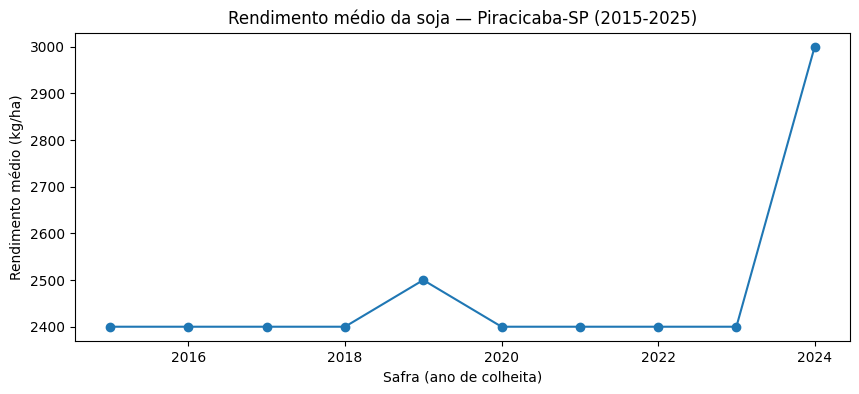

In [21]:
df_plot = df.sort_values("safra")

df_plot.plot(
    x="safra",
    y="Rendimento médio da produção",
    figsize=(10, 4),
    marker="o",
    title=f"Rendimento médio da soja — {config['local']} ({config['ano_inicial']}-{config['ano_final']})",
    legend=False,
)
plt.xlabel("Safra (ano de colheita)")
plt.ylabel("Rendimento médio (kg/ha)")
plt.show()

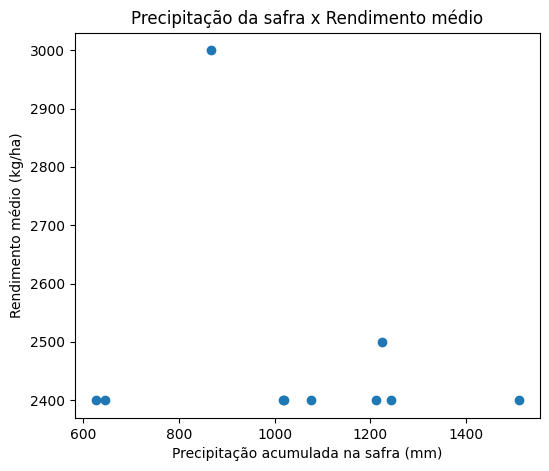

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(df["precipitacao_acumulada_mm"], df["Rendimento médio da produção"])
plt.xlabel("Precipitação acumulada na safra (mm)")
plt.ylabel("Rendimento médio (kg/ha)")
plt.title("Precipitação da safra x Rendimento médio")
plt.show()

## 12. Limitações registradas

- **NASA POWER** é dado modelado/reanálise, com resolução espacial de grade (~50x60 km) — não é medição exata no ponto de Piracicaba.
- **IBGE/PAM** é anual e tem defasagem de divulgação: safras muito recentes (ex.: 2025) podem ainda não aparecer na resposta — isso é esperado, não é erro de coleta.
- A definição de safra (set do ano anterior a abr do ano da safra) é uma aproximação para o Centro-Sul do Brasil; pode não refletir exatamente o calendário agrícola local de Piracicaba.
- `how="inner"` no merge descarta silenciosamente qualquer safra sem dado em uma das duas fontes — por isso o número de linhas final pode ser menor que 11 (2015-2025).